In [9]:
import math
import pandas as pd
import numpy as np
import yfinance as yf
import random
import matplotlib.pyplot as plt
from datetime import date
from scipy.stats import norm
from scipy.optimize import brentq



In [3]:

data = yf.download("BHARTIARTL.NS", start="2025-03-07", end="2026-03-07",auto_adjust=True)
data = pd.DataFrame(data)
closing_prices = data["Close"]
daily_returns = closing_prices.pct_change()

[*********************100%***********************]  1 of 1 completed


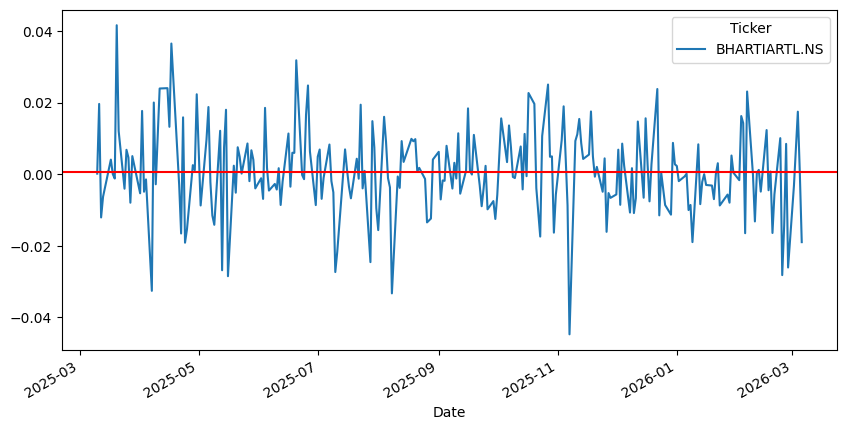

In [137]:
daily_returns = daily_returns.dropna()
daily_mean = daily_returns.mean()
daily_std = daily_returns.std()
annualized_mean = daily_mean * math.sqrt(252)
annualized_std = daily_std * math.sqrt(252)
daily_returns.plot(figsize=(10,5))
plt.axhline(y=daily_mean.item(), color='r', label=f'Mean: {daily_mean.item():.2f}')
plt.show()

In [ ]:
closing_prices.tail(1)

Ticker,BHARTIARTL.NS
Date,
2026-03-06,1870.800049


In [68]:
def black_scholes_price(S0,K,r,T1,t0,sigma):
  T = (T1-t0).days/252
  d2 = ((math.log(S0/K) + (r - (0.5 * annualized_std.item()**2)) * T)) / (annualized_std.item() * math.sqrt(T))
  d1 = d2 + (annualized_std.item() * math.sqrt(T))
  C = (S0 * norm.cdf(d1)) - (math.exp(-r * T) * K * norm.cdf(d2))
  print(d2)
  print(d1)
  print(f'The option price is:{C}')
  return C




In [138]:
S0= 1871  #round(closing_prices.iloc[-1]).astype(int)#spot price at t
K = 1900 #strike price
r = 6.68/100 # risk free rate
T1 = date(2026, 3,26 ) #expiry
t0 = date(2026, 3, 7) #todays date
T = 13/252 #(T1-t0).days/252
sigma = annualized_std
market_price = 51.75



In [ ]:
black_schole_call_price = black_scholes_price(S0,K,r,T1,t0,sigma)
print(f'{Black_Schole_Price:.2f} is the Back Schole Price')


-0.2232426593592374
-0.17072967835123426
The option price is:30.430411326459875
30.43 is the Back Schole Price


In [139]:
def black_scholes_call(S0,K,r,T,sigma):
    d1 = (math.log(S0/K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S0 * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)

def vega(S0,K,r,T,sigma):
    d1 = (math.log(S0/K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    return S0 * math.sqrt(T) * norm.pdf(d1)


# Step 3a: Newton-Raphson method
def iv_newton(market_price, S0, K, T, r, tol=1e-6, max_iter=100):
    sigma = 0.2  # initial guess
    for i in range(max_iter):
        price = black_scholes_call(S0,K,r,T,sigma)
        v = vega(S0,K,r,T,sigma)
        diff = market_price - price
        if abs(diff) < tol:
            return sigma
        sigma += diff / v   # update step
    return sigma

# Step 3b: Brentq method (more robust)
def iv_brentq(market_price, S0, K, T, r):
    objective = lambda sigma: black_scholes_call(S0,K,r,T,sigma) - market_price
    return brentq(objective, 1e-6, 10.0)  # search between 0% and 1000% vol




In [151]:
ivb = iv_brentq(market_price, S0, K, T, r)
ivnr = iv_newton(market_price, S0, K, T, r, tol=1e-6, max_iter=100)
black_schole_price = black_scholes_call(S0,K,r,T,sigma)
print(f"Sigma {annualized_std.item()*100 :.2f}%")
print(f"Implied Volatility brentq: {ivb*100:.3f}%")
print(f"Implied Volatility newton raphson: {ivnr*100:.2f}%")
print(f"Black Schole Price: {black_schole_price:.2f}")

Sigma 19.12%
Implied Volatility brentq: 36.562%
Implied Volatility newton raphson: 36.56%
Black Schole Price: 22.61


In [60]:
s=[]
s.append(1871)
for t in range ((T1-t0).days):
  r = random.normalvariate(mu=0, sigma=1)
  S = s[t] * math.exp((annualized_mean - (0.5 * annualized_std ** 2) ) * (1/252) + (annualized_std * r * math.sqrt(1/252)))
  s.append(S)

/tmp/ipykernel_424/88338252.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S = s[t] * math.exp((annualized_mean - (0.5 * annualized_std ** 2) ) * (1/252) + (annualized_std * r * math.sqrt(1/252)))


In [77]:
# all_paths=[]
# implied_volatility = 0.2961
# for path in range(100000):
#   s=[]
#   s.append(1871)
#   for t in range ((T1-t0).days):
#     r = random.normalvariate(mu=0, sigma=1)
#     S = s[t] * math.exp((annualized_mean - (0.5 * implied_volatility ** 2) ) * (1/252) + (implied_volatility * r * math.sqrt(1/252)))
#     s.append(S)
#   all_paths.append(s)


/tmp/ipykernel_424/3394270898.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S = s[t] * math.exp((annualized_mean - (0.5 * annualized_std ** 2) ) * (1/252) + (annualized_std * r * math.sqrt(1/252)))


In [159]:
import numpy as np

# Parameters
n_paths = 10000
n_steps = 13 #(T1 - t0).days
dt = 1 / 252

S0 = 1871
mu = annualized_mean.item()
sigma = ivnr

# Step 1: Generate random shocks
Z = np.random.normal(0, 1, (n_paths, n_steps))

# Step 2: Compute drift and diffusion
drift = (mu - 0.5 * sigma**2) * dt
diffusion = sigma * np.sqrt(dt) * Z

# Step 3: Log returns
log_returns = drift + diffusion

# Step 4: Cumulative sum (log space)
log_paths = np.cumsum(log_returns, axis=1)

# Step 5: Convert to price paths
all_paths = S0 * np.exp(log_paths)

# Step 6: Add initial price (t = 0)
all_paths = np.hstack((S0 * np.ones((n_paths, 1)), all_paths))

# Final outputs
# all_paths → full simulated paths
# last_prices → terminal prices
last_prices = all_paths[:, -1]

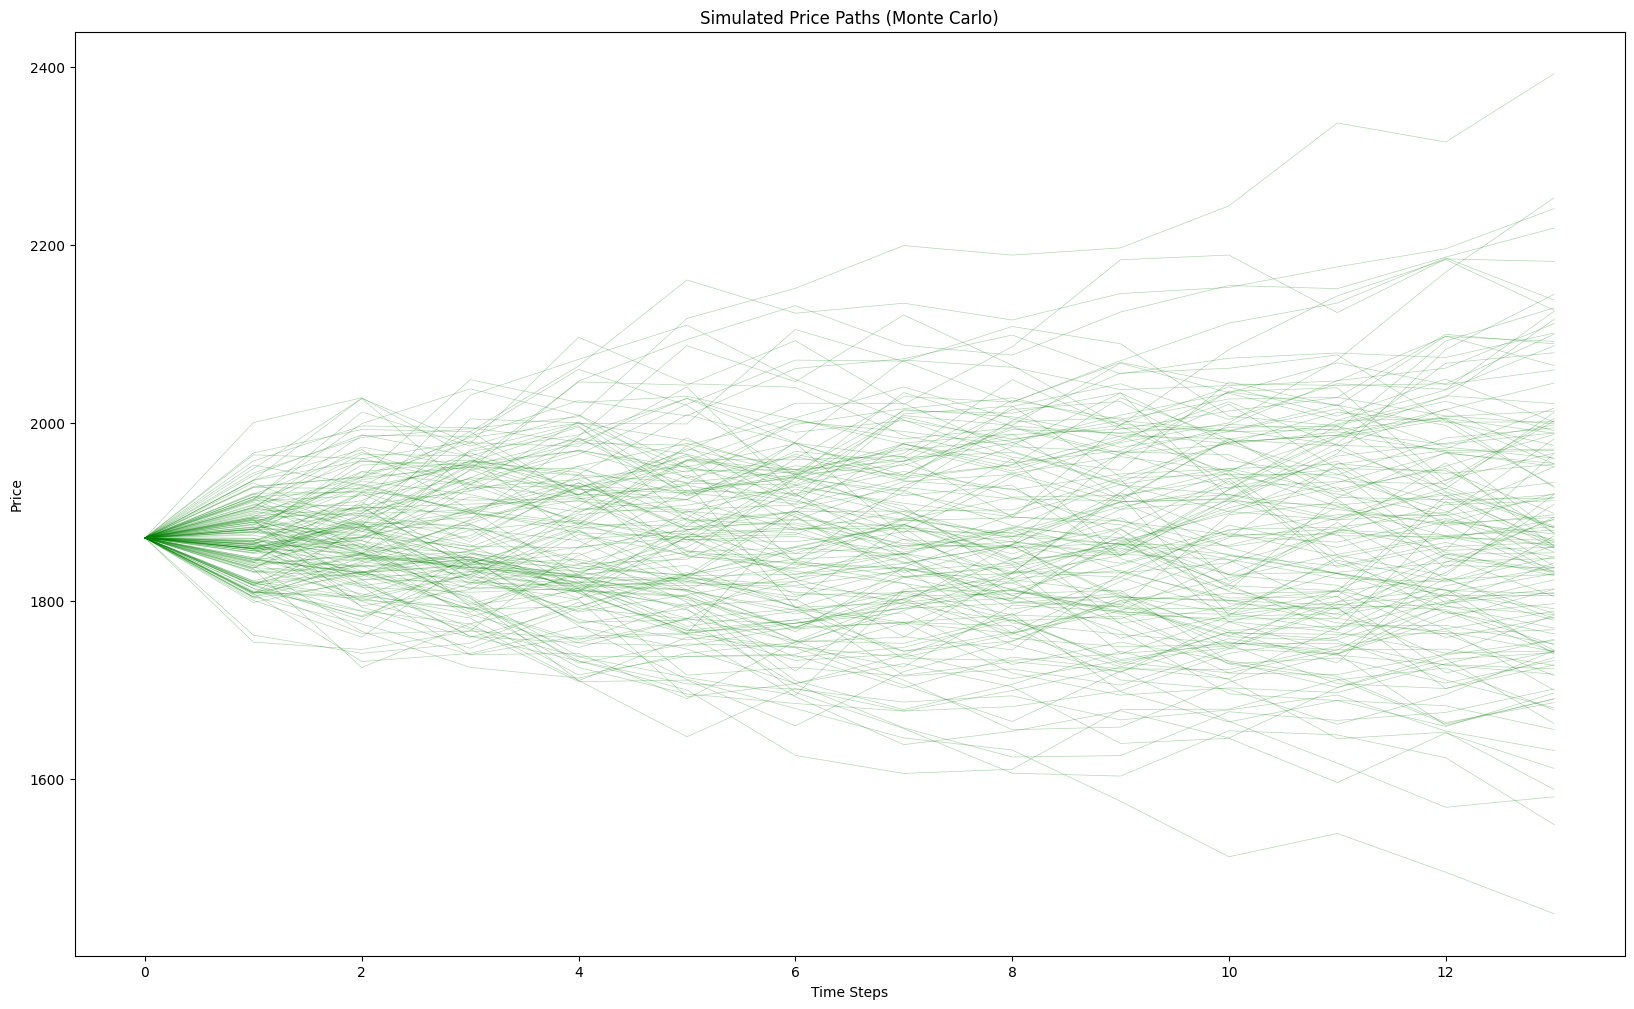

In [161]:
sim_paths = np.array(all_paths)

# Plot all paths
plt.figure(figsize=(20, 12))

for i in range(int((len(sim_paths)/64))):
    plt.plot(all_paths[i], linewidth=0.5, alpha=0.3, color = 'green')

plt.title("Simulated Price Paths (Monte Carlo)")
plt.xlabel("Time Steps")
plt.ylabel("Price")
plt.show()

In [160]:
last_prices = [path[-1] for path in all_paths]
K=1900
option_price=[]
for price in last_prices:
  if price-K > 0:
    option_price.append(price-K)
  else:
    option_price.append(0)
simulated_market_price = np.mean(option_price)
print(simulated_market_price)

50.27838433236639
